## Day 4

# Random Forest

In [1]:
# importing necessary lib
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.model_selection import train_test_split

In [2]:
# load the dataset 
df = pd.read_csv("agricultural sustainability.csv")

In [4]:
df.head()

,soil_health,crop_yield,water_usage,carbon_footprint,fertilizer_use,sustainability
0,0.374540,6778.284815,964.057410,126.020778,226.809659,0
1,0.950714,1757.259685,4561.488080,175.365653,88.134761,0
2,0.731994,2454.658427,2773.635676,129.654718,194.072090,0
3,0.598658,9086.987697,4219.058597,89.916140,201.678762,0
4,0.156019,6457.861537,1940.223205,104.286142,156.032668,0


In [5]:
df.shape

(200, 6)

In [6]:
df['sustainability'].unique()

array([0, 1])

In [7]:
df.columns

Index(['soil_health', 'crop_yield', 'water_usage', 'carbon_footprint',
       'fertilizer_use', 'sustainability'],
      dtype='object')

In [8]:
#features and target selcetion
X = df[['soil_health', 'crop_yield', 'water_usage', 'carbon_footprint',
       'fertilizer_use',]]
Y = df[['sustainability']]

In [9]:
# training and testing set split
X_train,X_test,Y_train,Y_test = train_test_split(X,Y,train_size=0.8,random_state=11)

In [10]:
X_train.shape

(160, 5)

In [11]:
Y_train.shape

(160, 1)

In [12]:
X_test.shape

(40, 5)

In [13]:
Y_test.shape

(40, 1)

In [16]:
#model
model = RandomForestClassifier(n_estimators=100,random_state=100)

In [17]:
#train the model
model.fit(X_train,Y_train)

C:\Users\HP\OneDrive\Attachments\Lib\site-packages\sklearn\base.py:1389: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)


RandomForestClassifier(random_state=100)

In [18]:
# predection
Y_pred = model.predict(X_test)
Y_pred

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0])

In [19]:
len(Y_pred)

40

In [20]:
# evuluate the model
acc = accuracy_score(Y_test,Y_pred)
print(f'The accuracy score for RFC is {acc*100:.2f}%')

The accuracy score for RFC is 100.00%


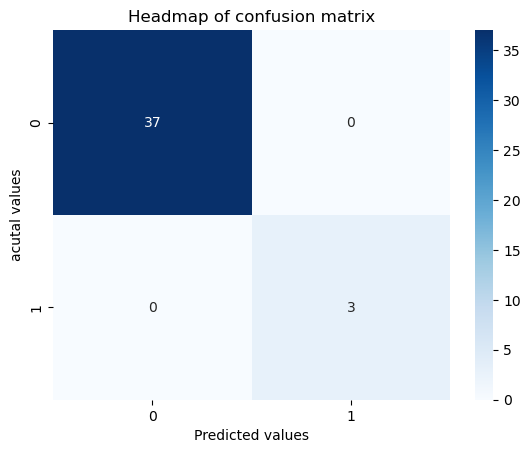

In [32]:
# confusion matrix
cm = confusion_matrix(Y_test,Y_pred)
sns.heatmap(cm,annot = True , cmap ='Blues')
xticklabel=['Unsustainable','Sustainable']
yticklabel=['Unsustainable','Sustainable']
plt.title('Headmap of confusion matrix')
plt.xlabel('Predicted values')
plt.ylabel('acutal values')
plt.show()

In [33]:
#classf report
cr = classification_report(Y_test,Y_pred)
print(cr)

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        37
           1       1.00      1.00      1.00         3

    accuracy                           1.00        40
   macro avg       1.00      1.00      1.00        40
weighted avg       1.00      1.00      1.00        40



In [35]:
# save model
import joblib
joblib.dump(model, 'DSK_Model.pkl')

['DSK_Model.pkl']